* In this notebook, we will collect 10 datasets and prepare them for next steps of data synthesis and classification.
* Mainly, we will perform data cleaning (checking labels), removing missing values and irrelevant features.

In [1]:
import pandas as pd
import numpy as numpy

In [4]:
import pandas as pd

def read_data_file(file_path):
    column_names = []
    data_start_index = 0
    with open(file_path, 'r') as file:
        for index, line in enumerate(file):
            if line.startswith('@inputs'):
                inputs = line.strip().split(' ', 1)[1]
                column_names.extend(inputs.split(', '))
            elif line.startswith('@output'):
                output = line.strip().split(' ', 1)[1]
                column_names.append(output)
            elif line.strip().lower() == '@data':
                data_start_index = index + 1
                break

    # Read the data into a DataFrame using the extracted column names and starting index
    data = pd.read_csv(file_path, skiprows=data_start_index, header=None, names=column_names, sep=' ')
    return data

# Define the path to your .data file
file_path = r'C:\Users\BOUKA\Downloads\VAE-Code\inputs\vertebral+column\column_2C.dat'

# Call the function and get the DataFrame
dataframe = read_data_file(file_path)

# Display the first few rows of the DataFrame
dataframe.head()


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.03,22.55,39.61,40.48,98.67,-0.25,AB
1,39.06,10.06,25.02,29.00,114.41,4.56,AB
2,68.83,22.22,50.09,46.61,105.99,-3.53,AB
3,69.30,24.65,44.31,44.64,101.87,11.21,AB
4,49.71,9.65,28.32,40.06,108.17,7.92,AB


In [5]:
dataframe['class'].value_counts()

class
AB    210
NO    100
Name: count, dtype: int64

In [6]:
dataframe.describe()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496484,17.542903,51.930710,42.953871,117.920548,26.296742
std,17.236109,10.008140,18.553766,13.422748,13.317629,37.558883
min,26.150000,-6.550000,14.000000,13.370000,70.080000,-11.060000
25%,46.432500,10.667500,37.000000,33.347500,110.710000,1.600000
50%,58.690000,16.360000,49.565000,42.405000,118.265000,11.765000
75%,72.880000,22.120000,63.000000,52.692500,125.467500,41.285000
max,129.830000,49.430000,125.740000,121.430000,163.070000,418.540000


In [7]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          310 non-null    float64
 1   pelvic_tilt               310 non-null    float64
 2   lumbar_lordosis_angle     310 non-null    float64
 3   sacral_slope              310 non-null    float64
 4   pelvic_radius             310 non-null    float64
 5   degree_spondylolisthesis  310 non-null    float64
 6   class                     310 non-null    object 
dtypes: float64(6), object(1)
memory usage: 17.1+ KB


In [8]:
dataframe.shape

(310, 7)

In [9]:
for col in dataframe.columns:
    print(dataframe[col].value_counts())

pelvic_incidence
63.03    2
53.94    2
50.91    2
42.52    2
65.01    2
        ..
49.78    1
70.40    1
79.94    1
84.59    1
33.84    1
Name: count, Length: 301, dtype: int64
pelvic_tilt
 8.40     2
 26.33    2
 5.27     2
 17.44    2
 16.74    2
         ..
-6.55     1
 19.28    1
 36.84    1
 12.49    1
 5.07     1
Name: count, Length: 291, dtype: int64
lumbar_lordosis_angle
42.00    4
58.00    4
35.00    4
47.00    4
52.00    4
        ..
48.50    1
86.96    1
48.38    1
62.42    1
36.64    1
Name: count, Length: 271, dtype: int64
sacral_slope
56.31     4
45.00     3
35.42     3
53.13     3
33.11     3
         ..
50.48     1
44.14     1
121.43    1
57.99     1
28.77     1
Name: count, Length: 276, dtype: int64
pelvic_radius
129.39    2
116.59    2
116.56    2
110.71    2
116.80    2
         ..
116.58    1
118.45    1
110.86    1
102.34    1
123.95    1
Name: count, Length: 303, dtype: int64
degree_spondylolisthesis
-4.08     2
 4.96     2
-2.01     2
 3.09     2
 1.01     2
    

<Axes: >

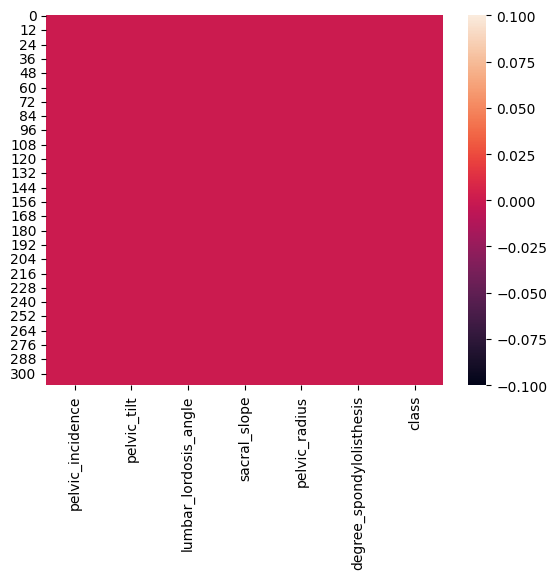

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(dataframe.isnull())

In [14]:
dataframe['Class'].value_counts()

Class
negative    338
positive     20
Name: count, dtype: int64

In [13]:
dataframe['class'].replace("AB", 1, inplace=True)
dataframe['class'].replace("NO", 0, inplace=True)

In [14]:
dataframe['class'].unique()

array([1, 0], dtype=int64)

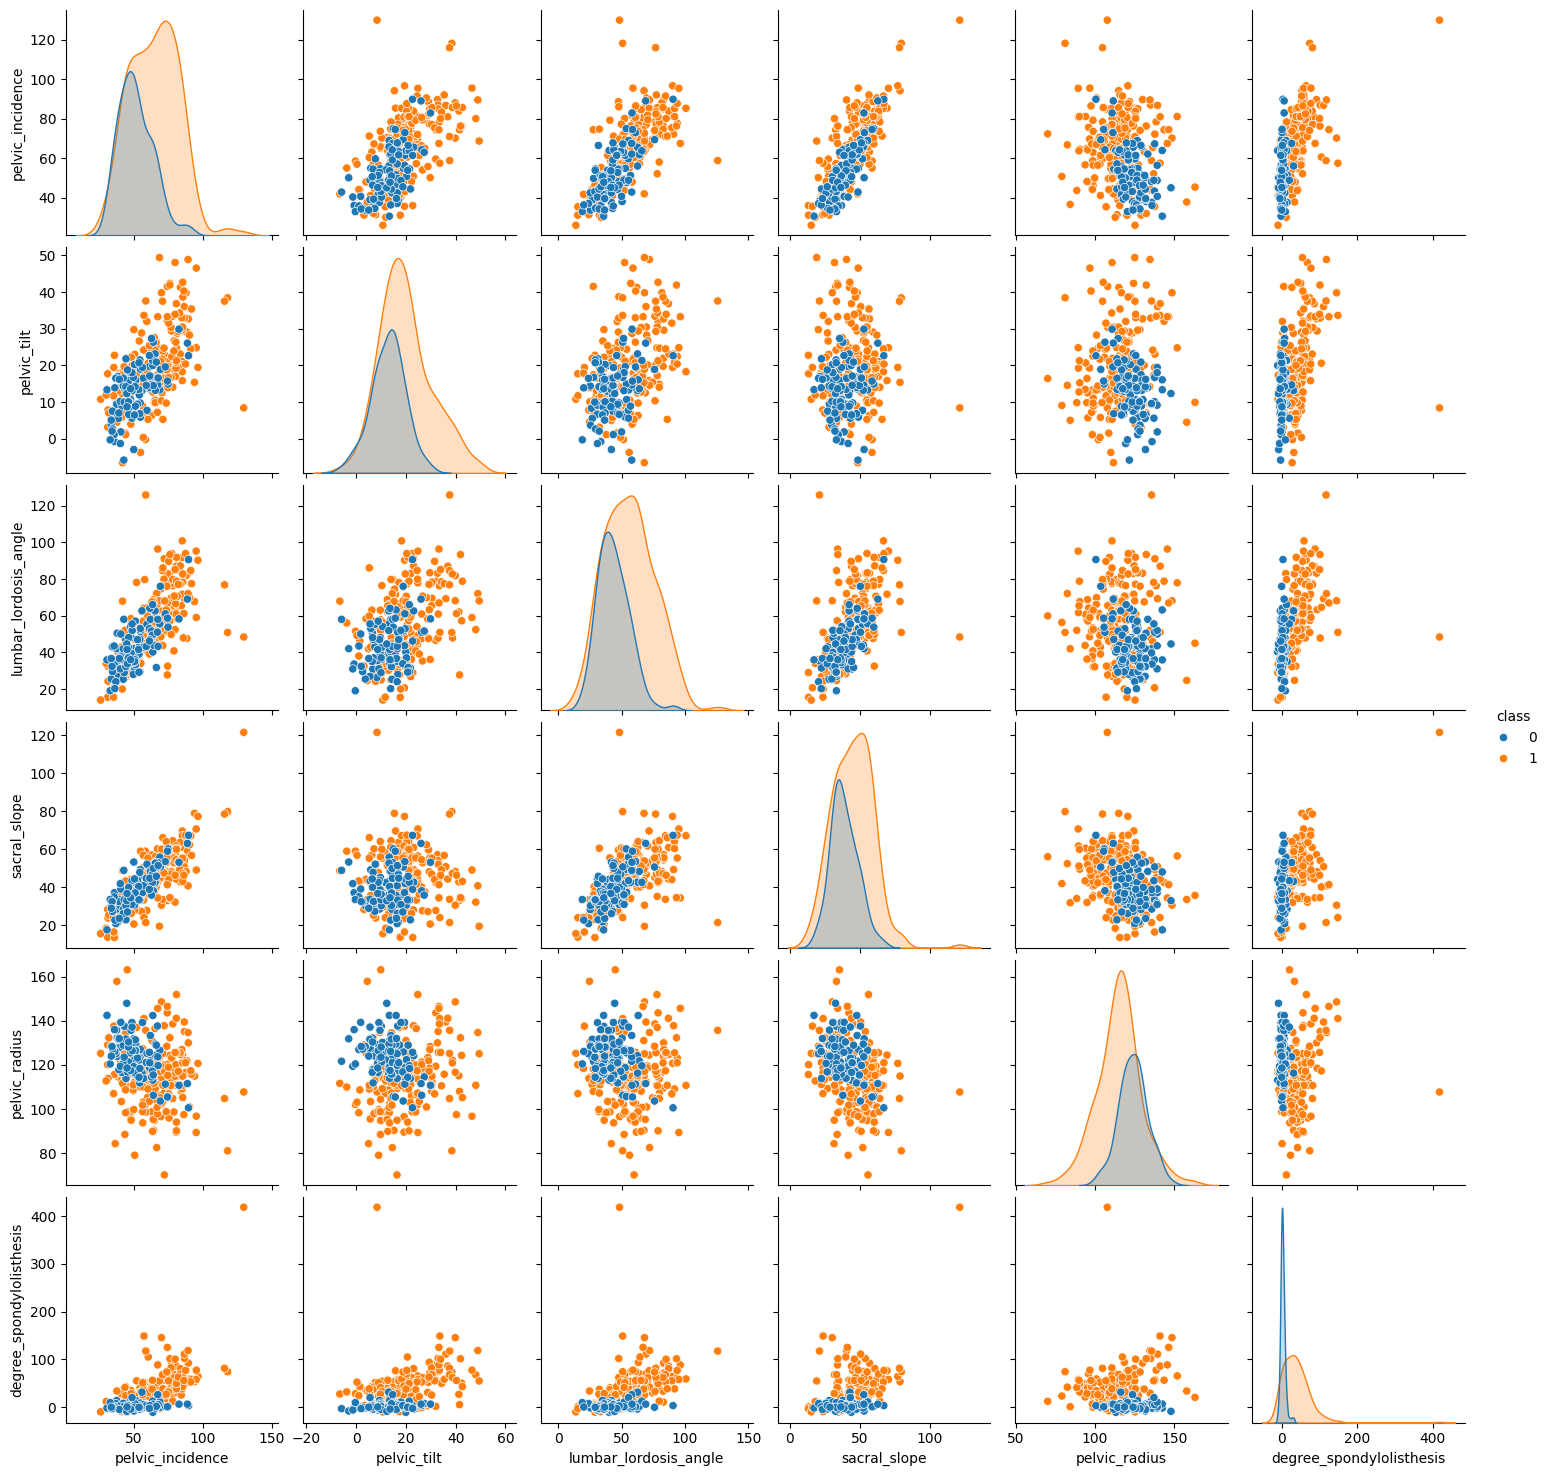

In [15]:
sns.pairplot(data=dataframe, hue='class')

In [16]:
dataframe.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.03,22.55,39.61,40.48,98.67,-0.25,1
1,39.06,10.06,25.02,29.00,114.41,4.56,1
2,68.83,22.22,50.09,46.61,105.99,-3.53,1
3,69.30,24.65,44.31,44.64,101.87,11.21,1
4,49.71,9.65,28.32,40.06,108.17,7.92,1


In [17]:
dataframe = dataframe.rename(columns={"class": "Outcome"})

<Axes: >

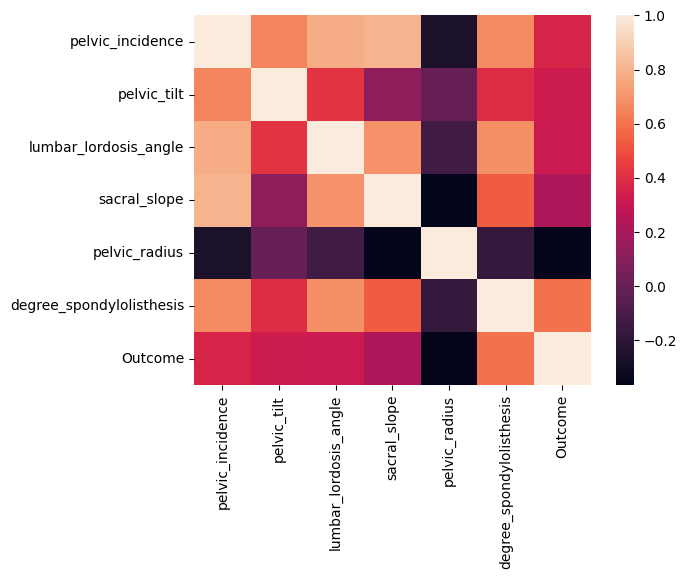

In [18]:
corr = dataframe.corr(method="spearman")
sns.heatmap(corr,annot=False)

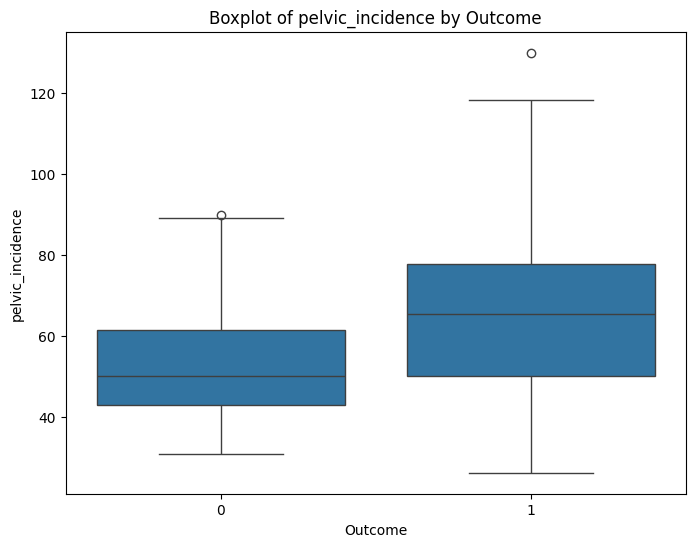

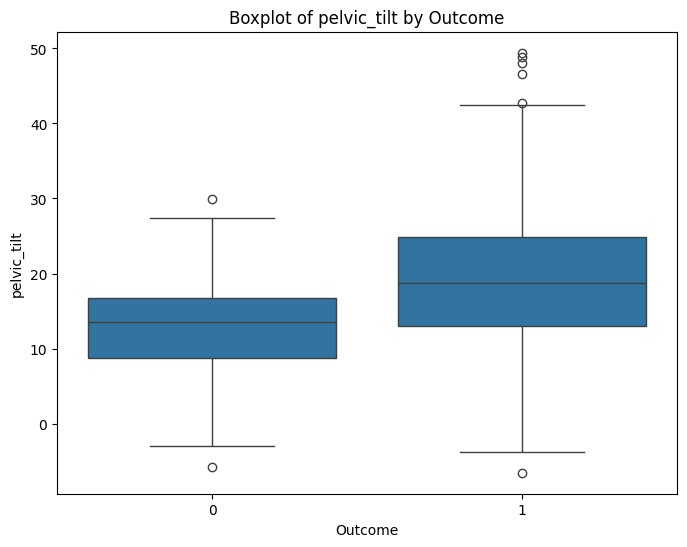

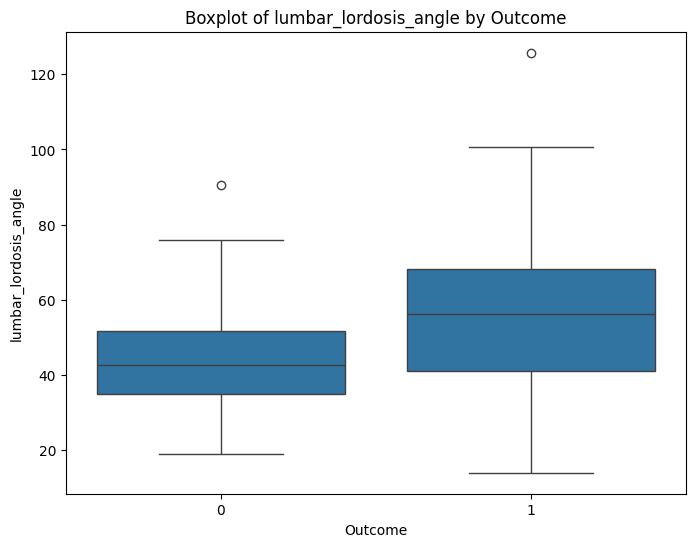

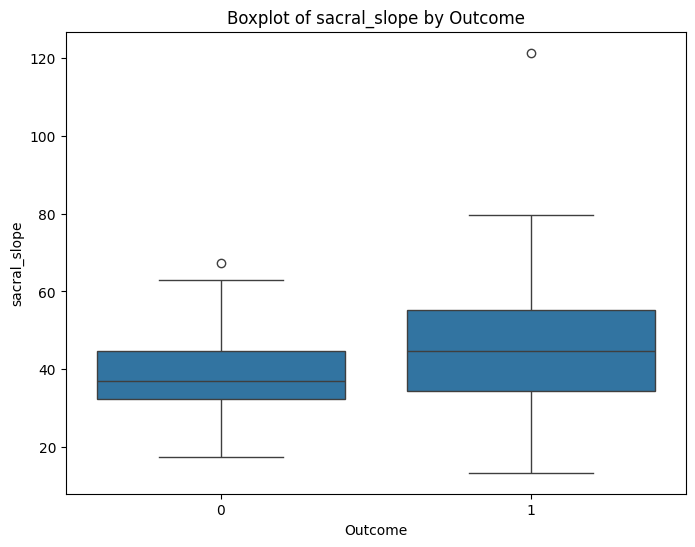

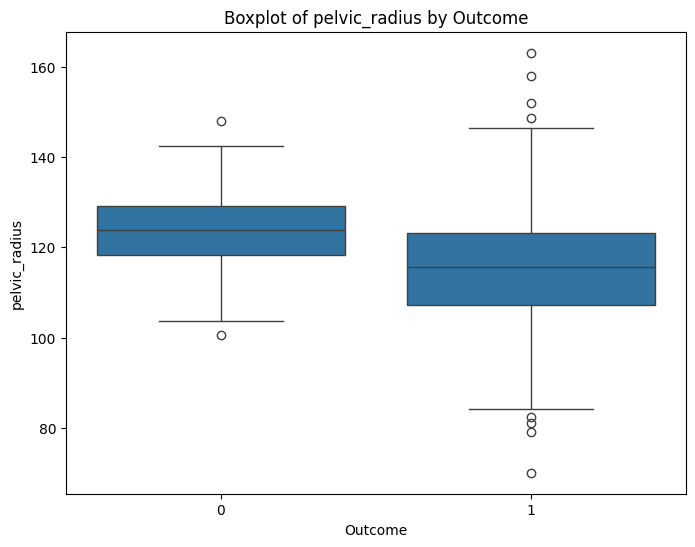

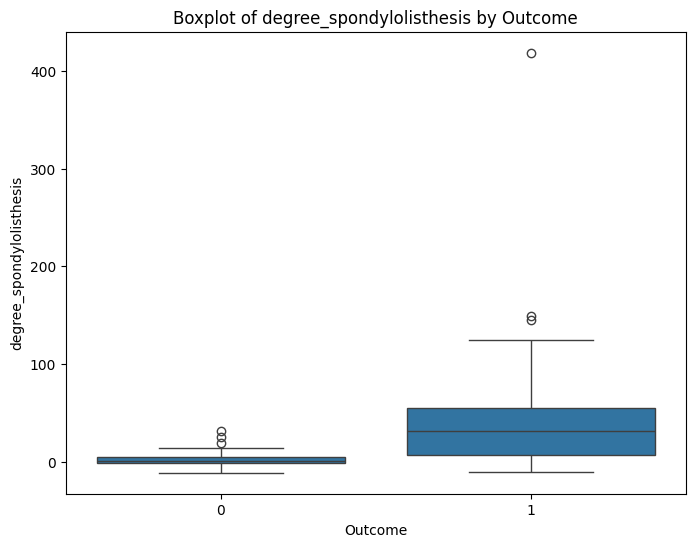

In [19]:
cols = [col for col in dataframe.columns if col!="Outcome"]
for col in cols:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=dataframe, x="Outcome", y=col)
        plt.title(f'Boxplot of {col} by Outcome')
        plt.show()

In [20]:
def removeOutlier(col):
    sorted(col)
    quant1, quant2 = col.quantile([0.25, 0.75])
    IQR = quant2 - quant1
    lowerRange = quant1 - (1.5 * IQR)
    upperRange = quant2 + (1.5 * IQR)
    return lowerRange, upperRange

In [22]:
import numpy as np
for col in cols:
    lowScore, highScore = removeOutlier(dataframe[col])
    print(f"Column: {col}, Lower Bound: {lowScore}, Upper Bound: {highScore}")
    dataframe[col] = np.where(dataframe[col]>highScore, highScore, dataframe[col])
    dataframe[col] = np.where(dataframe[col]<lowScore, lowScore, dataframe[col])

Column: pelvic_incidence, Lower Bound: 6.761249999999997, Upper Bound: 112.55125
Column: pelvic_tilt, Lower Bound: -6.51125, Upper Bound: 39.29875
Column: lumbar_lordosis_angle, Lower Bound: -2.0, Upper Bound: 102.0
Column: sacral_slope, Lower Bound: 4.330000000000005, Upper Bound: 81.71000000000001
Column: pelvic_radius, Lower Bound: 88.57374999999999, Upper Bound: 147.60375000000002
Column: degree_spondylolisthesis, Lower Bound: -57.9275, Upper Bound: 100.8125


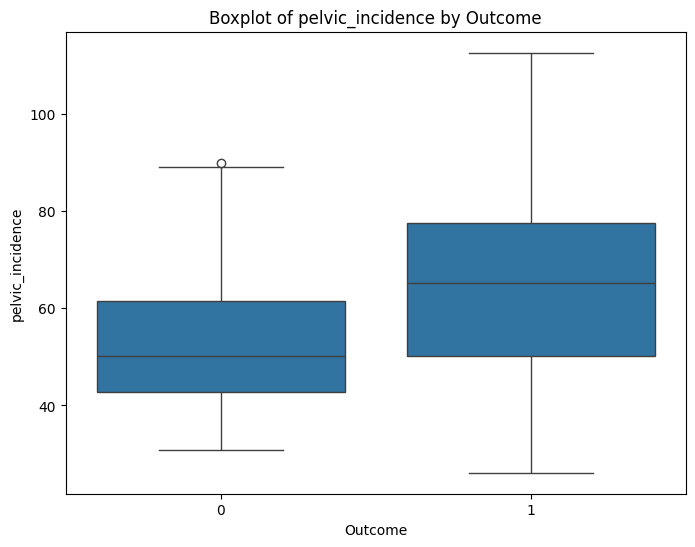

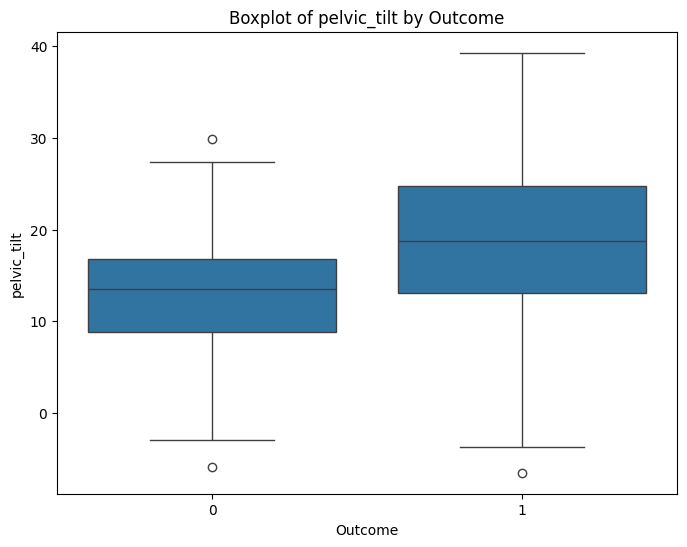

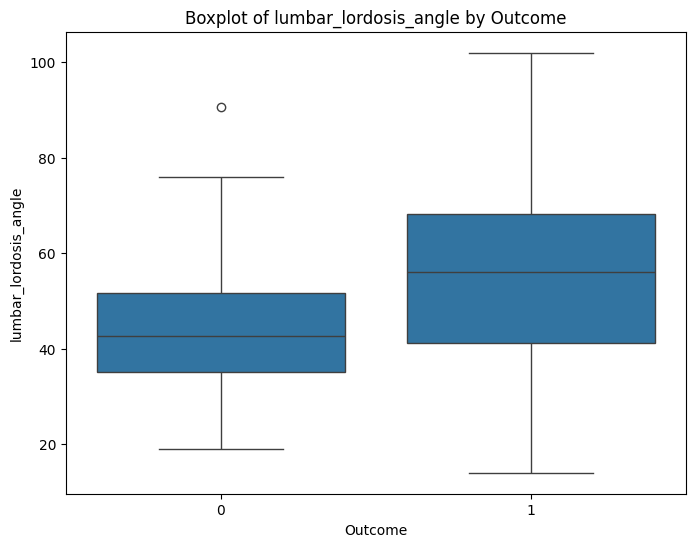

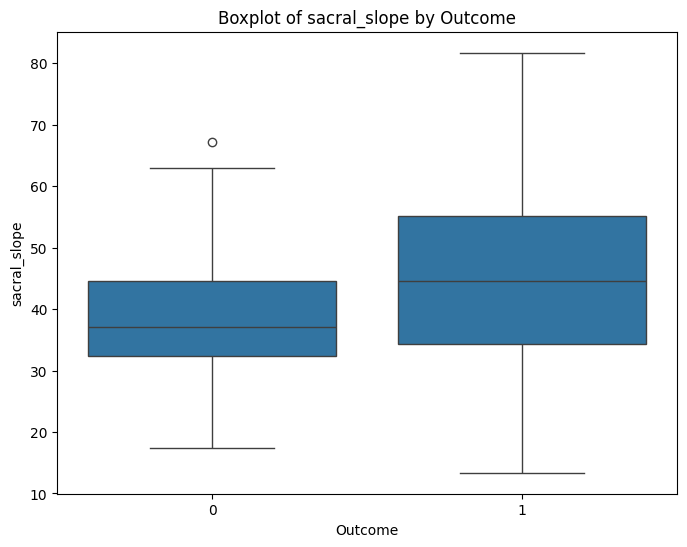

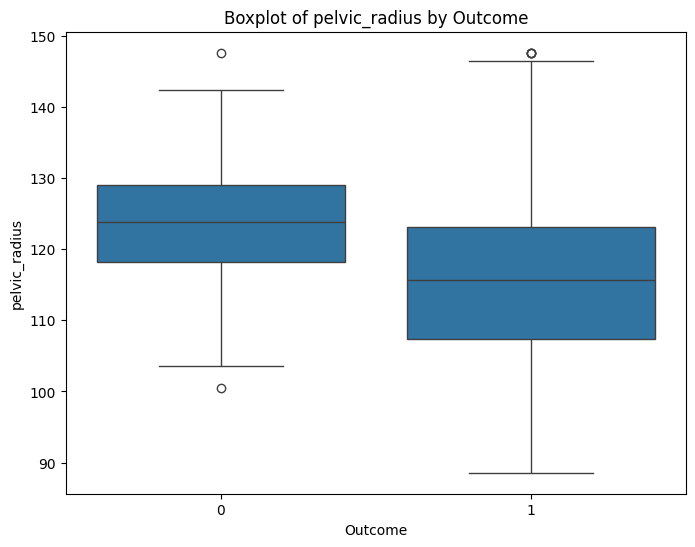

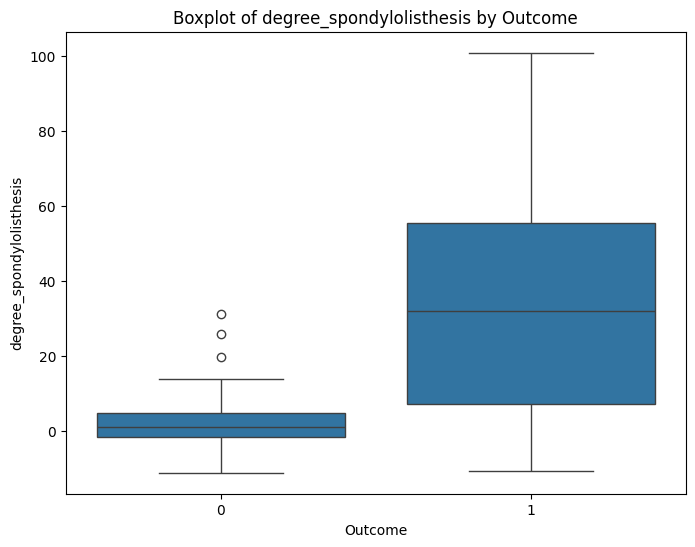

In [23]:
cols = [col for col in dataframe.columns if col!="Outcome"]
for col in cols:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=dataframe, x="Outcome", y=col)
        plt.title(f'Boxplot of {col} by Outcome')
        plt.show()

In [24]:
dataframe.to_csv(path_or_buf="Vertebral_processed.csv")